In [29]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils import dados, pivot, salvar

In [16]:
# Dados

dados_brutos, metadados, variaveis = dados(r"data\input\dados_brutos.xlsx")

dados_limpos, metadados, variaveis = dados(r"data\input\dados_limpos.xlsx")

imput_mean_limpos, metadados, variaveis = dados(r"data\input\imput_mean_limpos.xlsx")

imput_median_limpos, metadados, variaveis = dados(r"data\input\imput_median_limpos.xlsx")

imput_knn_limpos, metadados, variaveis = dados(r"data\input\imput_knn_limpos.xlsx")

imput_mean_zscore, metadados, variaveis = dados(r"data\input\imput_mean_zscore.xlsx")

imput_median_zscore, metadados, variaveis = dados(r"data\input\imput_median_zscore.xlsx")

imput_knn_zscore, metadados, variaveis = dados(r"data\input\imput_knn_zscore.xlsx")

imput_mean_iqr, metadados, variaveis = dados(r"data\input\imput_mean_iqr.xlsx")

imput_median_iqr, metadados, variaveis = dados(r"data\input\imput_median_iqr.xlsx")

imput_knn_iqr, metadados, variaveis = dados(r"data\input\imput_knn_iqr.xlsx")

In [17]:
type(dados_brutos)

pandas.core.frame.DataFrame

# K-Means - Clustering

Os dados normalizados serão preparados selecionando variáveis relevantes (ex.: pH, condutividade elétrica, nitrato). 

O algoritmo será aplicado para agrupar os dados por similaridade, testando n_clusters de 2 a 10, definido pelo método do cotovelo (Kaufman; Russeeuw, 1990). 

O objetivo é identificar padrões espaciais ou temporais (ex.: regiões com alta turbidez) para manejo hídrico. 

In [ ]:
from sklearn.cluster import KMeans

X = dados_limpos[variaveis].copy()

Xnonan = X.dropna()

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(Xnonan)

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
kmeans.labels_

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = dados_limpos[variaveis].copy()

X_nonan = X.dropna(axis=0, how='any')
idx_nonan = X_nonan.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nonan)

pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(X_pca)
distancias = np.linalg.norm(X_pca - kmeans.cluster_centers_[cluster_labels], axis=1)

In [ ]:
kmeans.labels_

# distancias

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,

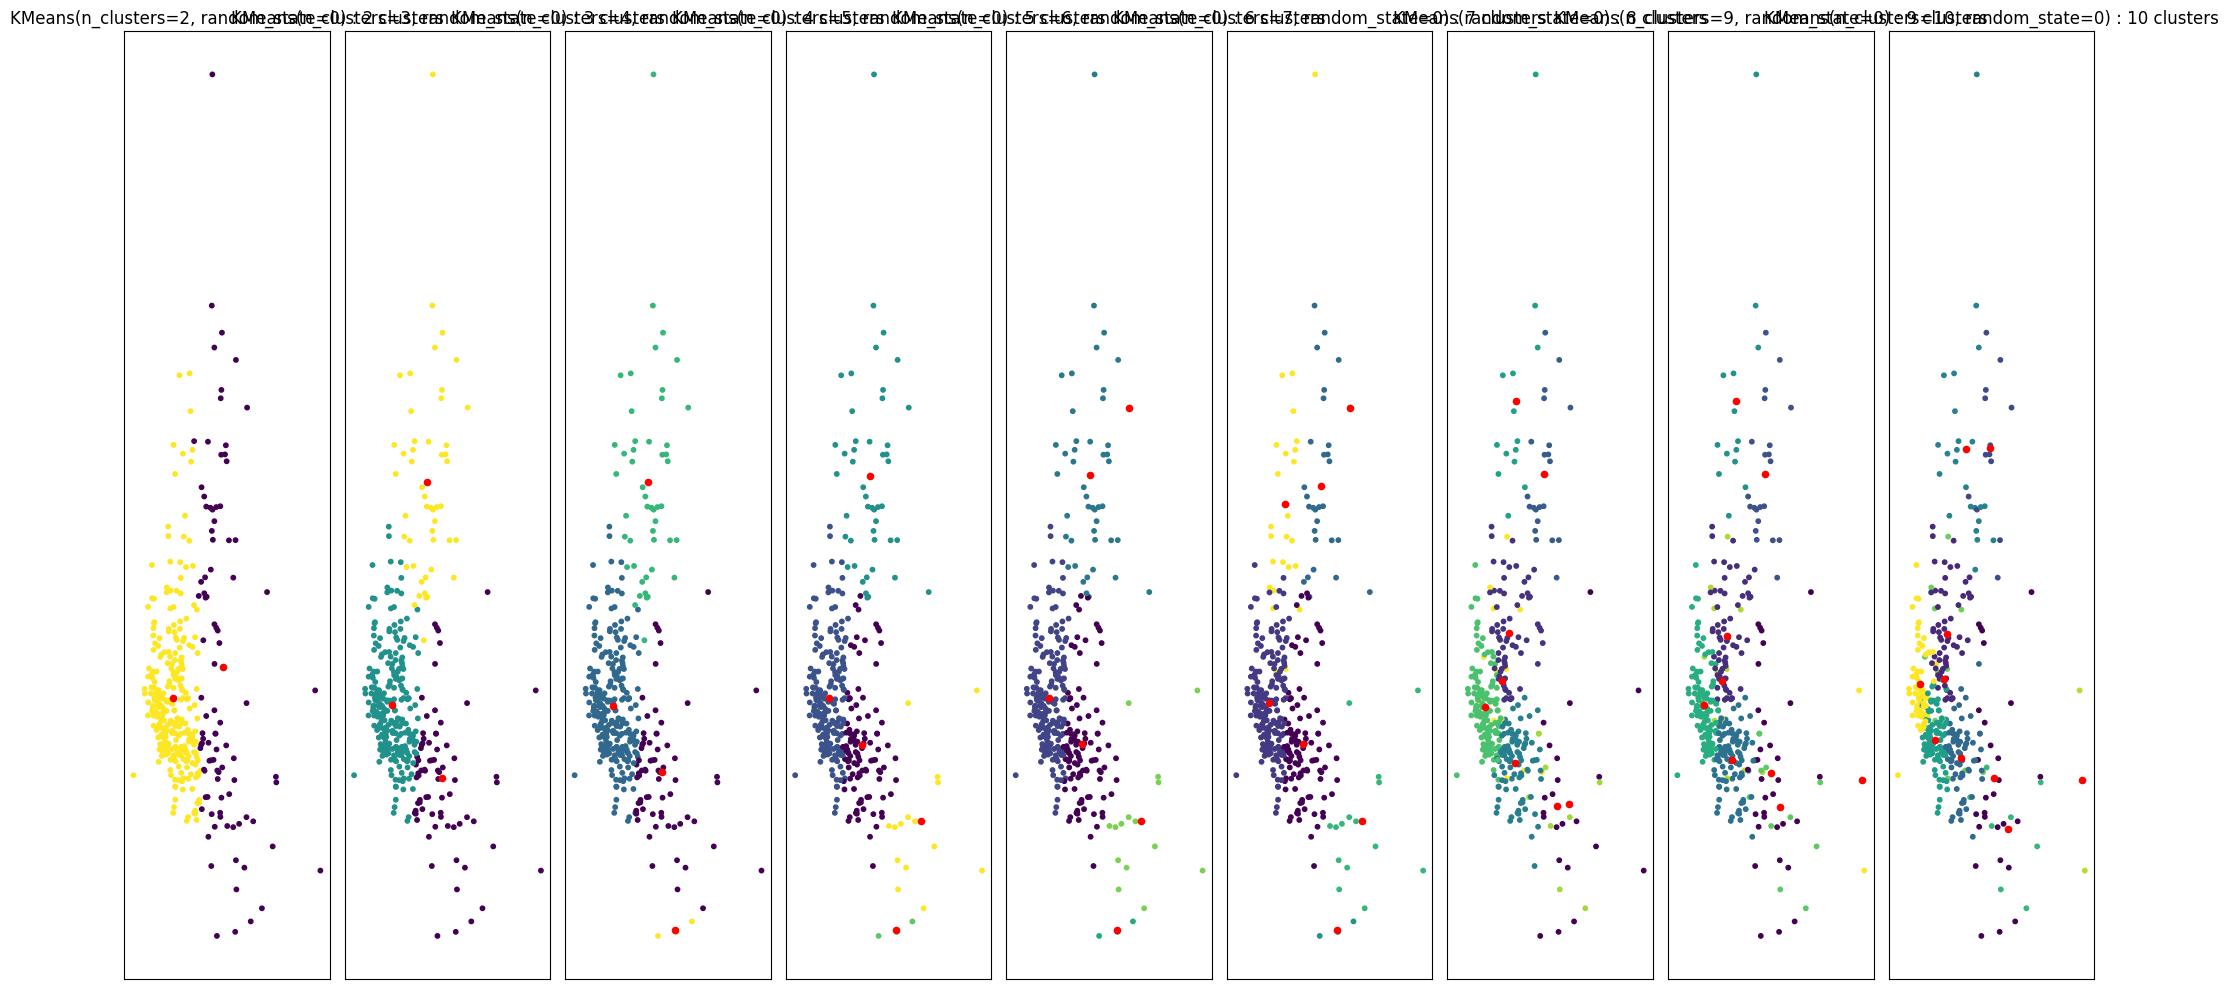

In [37]:
n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, axs = plt.subplots(
    1,
    len(n_clusters_list),
    figsize=(20, 10)
)

axs = axs.T

for i, n_clusters in enumerate(n_clusters_list):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_pca)
    centers = kmeans.cluster_centers_

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=kmeans.labels_)
    axs[i].scatter(centers[:, 0], centers[:, 1], c="r", s=20)

    axs[i].set_title(f"{kmeans} : {n_clusters} clusters")

for ax in axs.flat:
    ax.label_outer()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

# Random Forest - Classificação

Os dados serão divididos em treinamento (80%) e teste (20%). 

O modelo será treinado com n_estimators=100 e profundidade limitada para evitar overfitting, classificando a qualidade da água (ex.: adequada/inadequada, conforme Resolução 
CONAMA 357/2005, Brasil, 2012).  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Isolation Forest - Detecção de Anomalias

Após clustering, os dados serão processados para detectar anomalias isoladas, ajustando contamination (0,05–0,1) com base na análise exploratória. 

O algoritmo identificará picos de contaminação (ex.: fósforo elevado), focando em eventos críticos. 

In [ ]:
from sklearn.ensemble import IsolationForest